In [4]:
!pip install osmnx


In [5]:
import osmnx as ox

import warnings
warnings.filterwarnings('ignore')

city = '5th district, Budapest'

1. Demo


<Axes: >

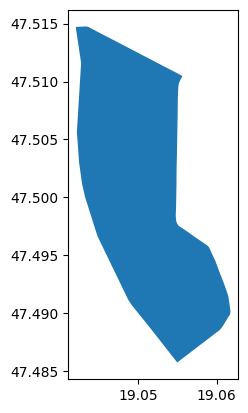

In [6]:
admin = ox.geocode_to_gdf(city)
admin.plot()

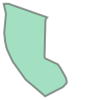

In [7]:
admin_poly = admin.geometry.to_list()[0]
admin_poly

In [8]:
G = ox.graph_from_polygon(admin_poly)

In [9]:
type(G)

networkx.classes.multidigraph.MultiDiGraph

In [10]:
G.number_of_nodes(), G.number_of_edges()

(1414, 3641)

In [11]:
nodes, edges = ox.graph_to_gdfs(G)

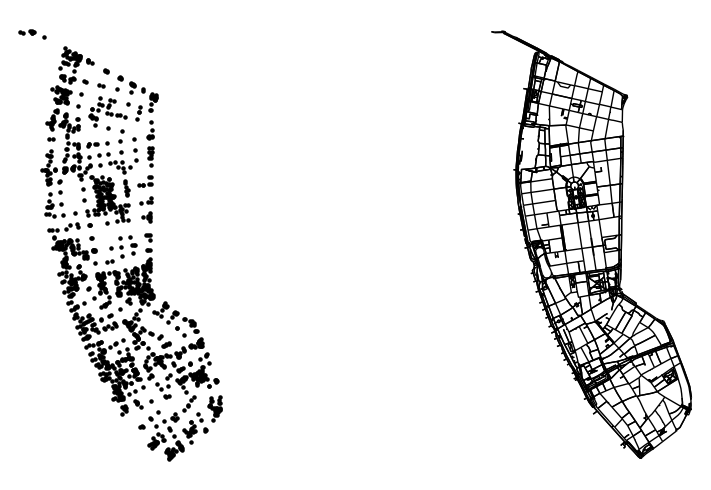

In [12]:
import matplotlib.pyplot as plt
f, ax = plt.subplots(1,2,figsize=(12,5))
nodes.plot(ax=ax[0], color = 'k', markersize = 5)
edges.plot(ax=ax[1], color = 'k', linewidth = 1)

for aax in ax:
  aax.axis('off')

plt.tight_layout()

2. Multi-city code


In [13]:
cities = ['Tokyo, Japan',
          'Delhi, India',
          'Barcelona, Spain',
          'Dhaka, Bangladesh',
          'Sao Paulo, Brazil',
          'Budapest, Hungary']

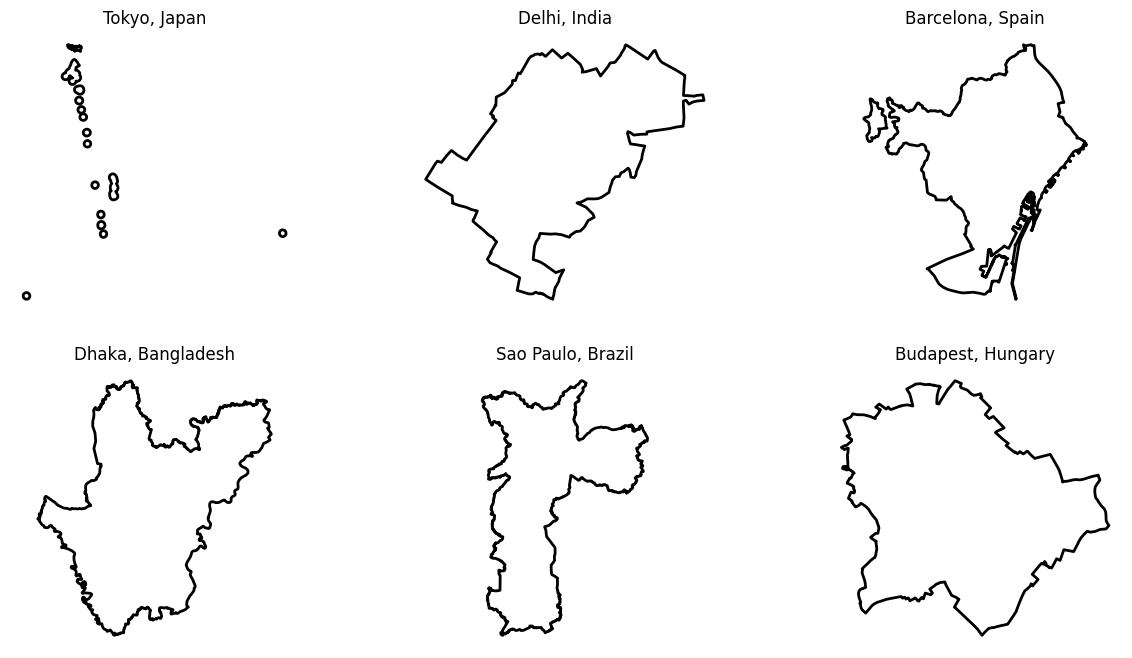

In [14]:
f, ax = plt.subplots(2,3, figsize=(15,8))

indicidies = [(i, j) for i in range(2) for j in range(3)]

for idx, city in enumerate(cities):
  bx = ax[indicidies[idx]]
  admin = ox.geocode_to_gdf(city)
  admin.plot(ax=bx, color = 'none', edgecolor = 'k', linewidth = 2)
  bx.axis('off')
  bx.set_title(city)

Text(0.5, 1.0, 'Tokyo, Japan')

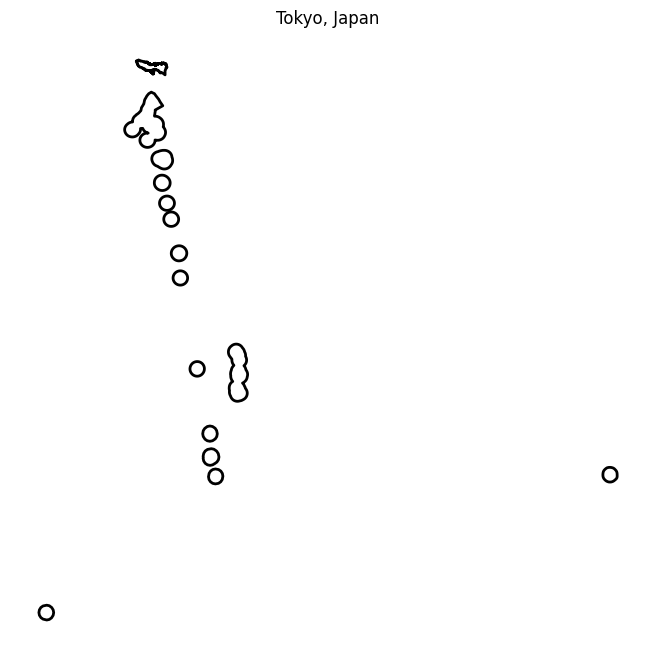

In [15]:
city = 'Tokyo, Japan'

f, ax = plt.subplots(1,1, figsize=(15,8))

admin = ox.geocode_to_gdf(city)
admin.plot(ax=ax, color = 'none', edgecolor = 'k', linewidth = 2)
ax.axis('off')
ax.set_title(city)

In [16]:
admin_exp = admin.explode()
len(admin_exp)


19

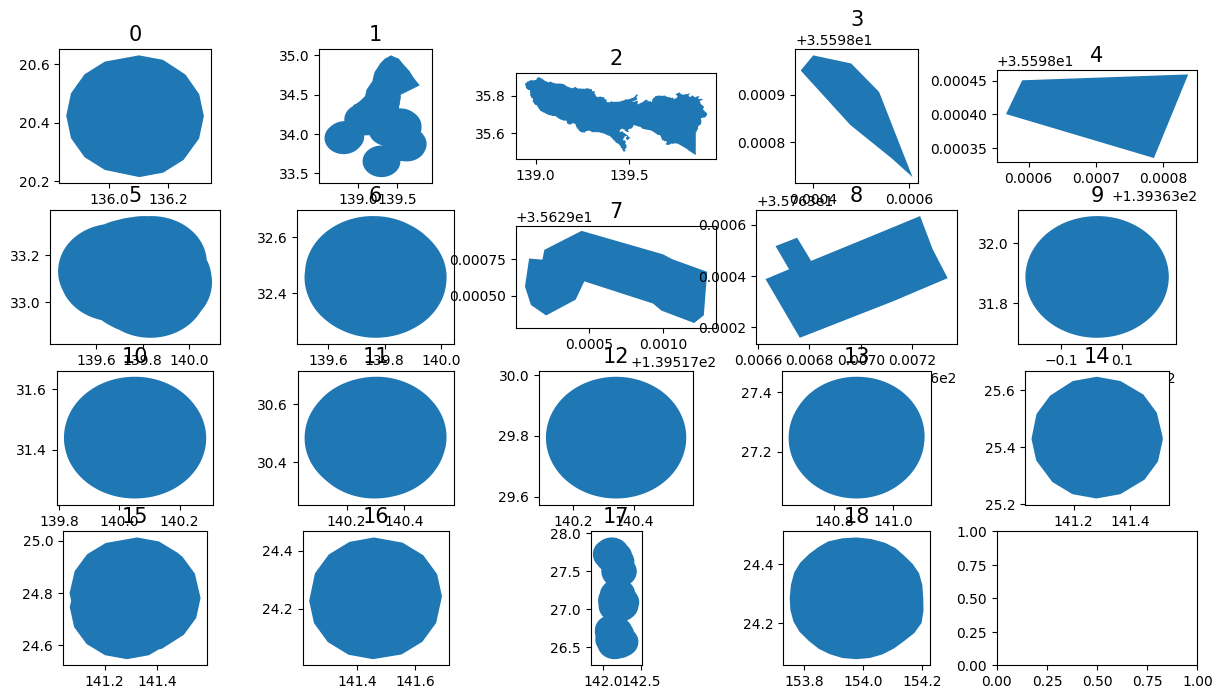

In [19]:
import geopandas as gpd
f, ax = plt.subplots(4,5,figsize=(15,8))
indicies = [(i, j) for i in range(4) for j in range(5)]

for idx in range(len(admin_exp)):
  bx = ax[indicies[idx]]

  admin_exp_segment = gpd.GeoDataFrame(admin_exp.iloc[idx]).T
  admin_exp_segment.geometry = admin_exp_segment['geometry']
  admin_exp_segment.plot(ax=bx)
  bx.set_title(idx, fontsize = 15)




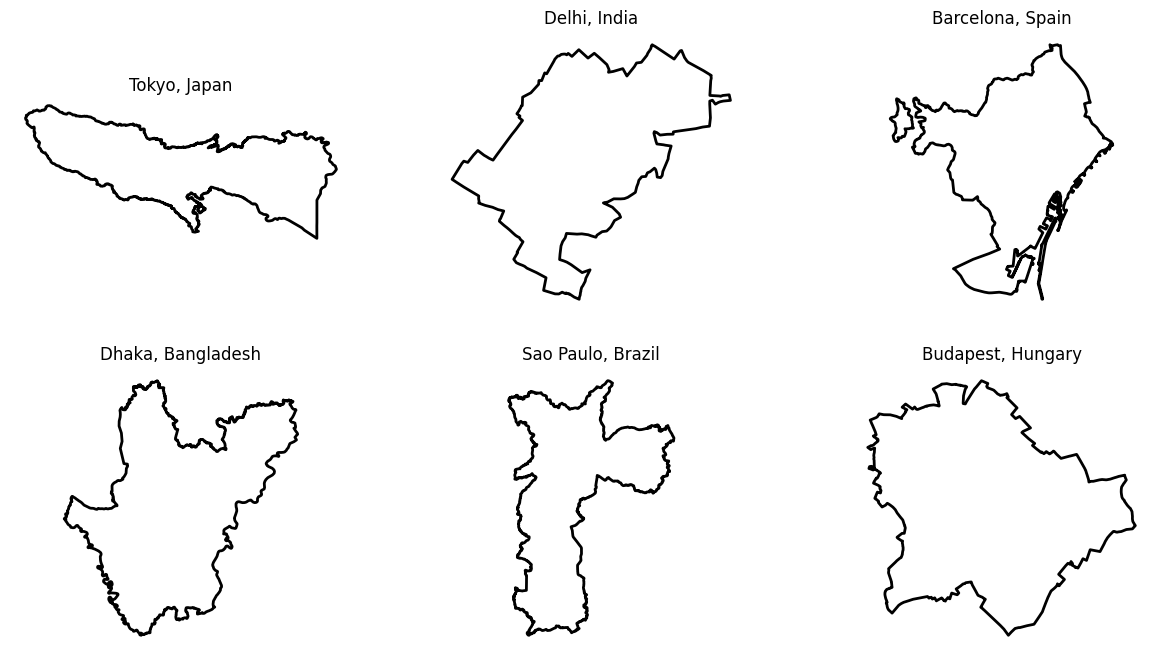

In [20]:
f, ax = plt.subplots(2,3, figsize=(15,8))

cities_admins = {}
indicidies = [(i, j) for i in range(2) for j in range(3)]

for idx, city in enumerate(cities):
  if city != 'Tokyo, Japan':
    admin = ox.geocode_to_gdf(city)
  else:
    admin = ox.geocode_to_gdf(city)
    admin_exp = admin.explode()
    admin_exp_segment = gpd.GeoDataFrame(admin_exp.iloc[2]).T
    admin_exp_segment.geometry = admin_exp_segment['geometry']
    admin = admin_exp_segment
    #admin = admin_exp.iloc[2]

  cities_admins[city] = admin
  bx = ax[indicidies[idx]]
  # The following line was overwriting the specific Tokyo segment, it is removed.
  # admin = ox.geocode_to_gdf(city)
  admin.plot(ax=bx, color = 'none', edgecolor = 'k', linewidth = 2)
  bx.axis('off')
  bx.set_title(city)

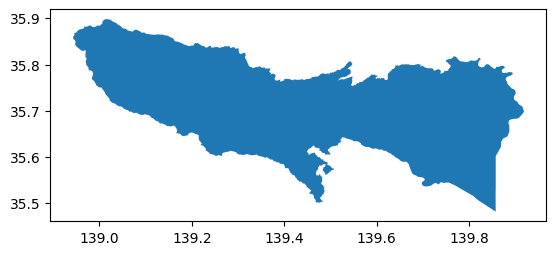

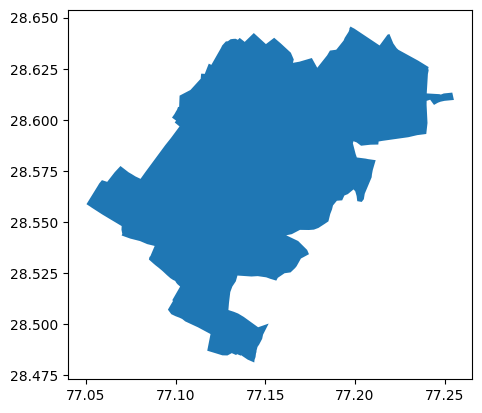

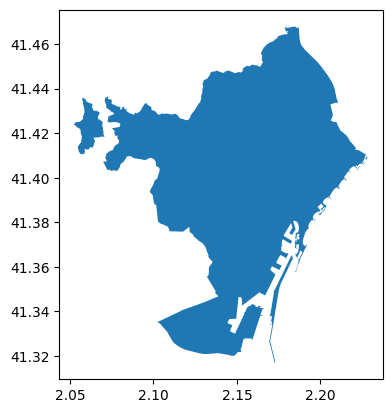

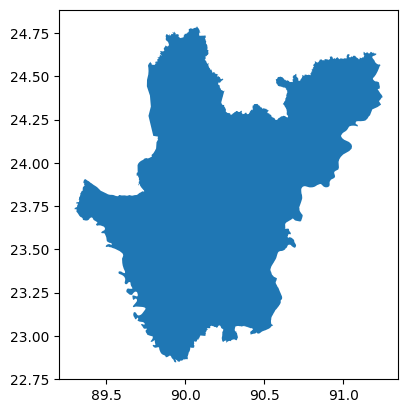

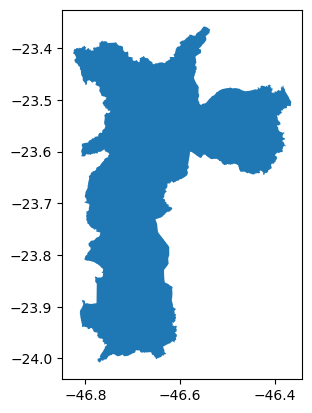

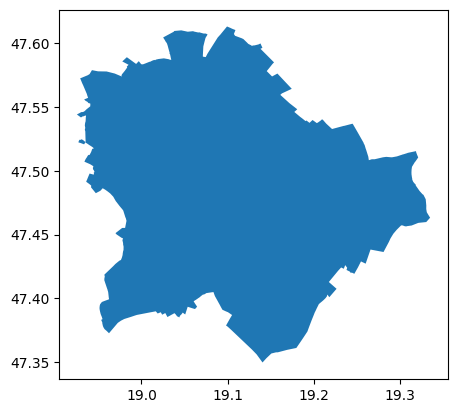

In [21]:
for city, admin in cities_admins.items():
  admin.plot()

Tokyo, Japan 203456
Delhi, India 10159
Barcelona, Spain 8906
Dhaka, Bangladesh 103376
Sao Paulo, Brazil 122736
Budapest, Hungary 24299


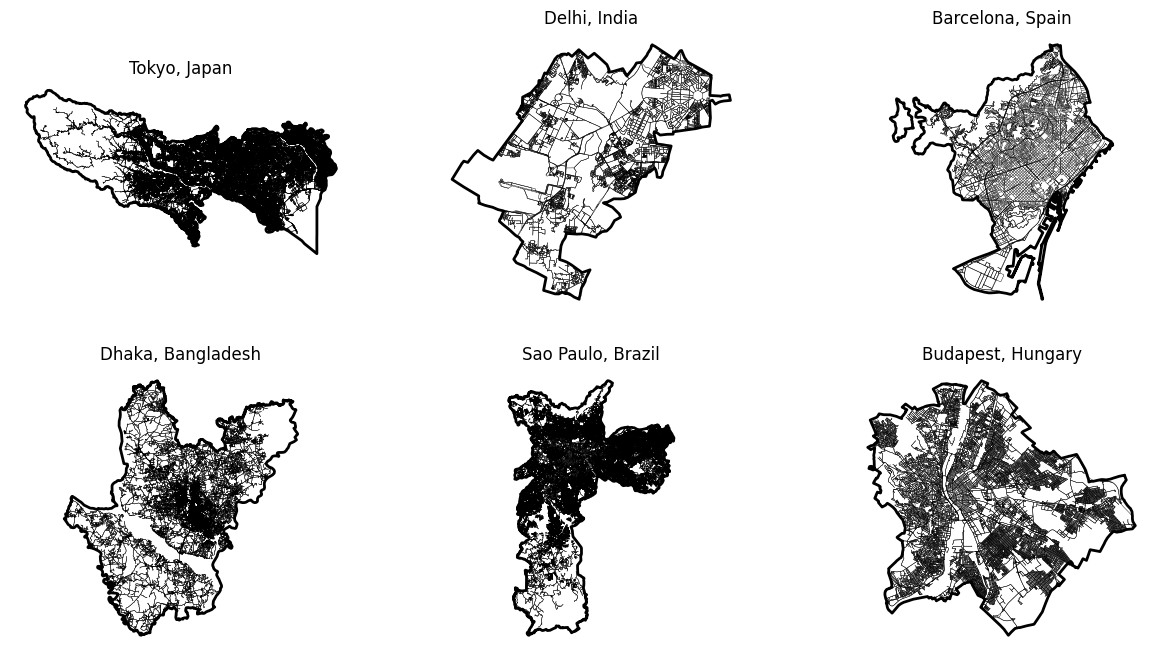

In [22]:
f, ax = plt.subplots(2,3, figsize=(15,8))
indicidies = [(i, j) for i in range(2) for j in range(3)]



for idx, (city, admin) in enumerate(cities_admins.items()):

  admin_poly = admin.geometry.to_list()[0]
  G = ox.graph_from_polygon(admin_poly, network_type = 'drive' )
  print(city, G.number_of_nodes())
  nodes, edges = ox.graph_to_gdfs(G)

  bx = ax[indicidies[idx]]
  # The following line was overwriting the specific Tokyo segment, it is removed.
  # admin = ox.geocode_to_gdf(city)
  admin.plot(ax=bx, color = 'none', edgecolor = 'k', linewidth = 2)

  edges.plot(ax=bx, color = 'k', linewidth = 0.3)

  bx.axis('off')
  bx.set_title(city)